In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.7 MB/s eta 0:00:00


In [3]:
!cp -r "/content/drive/MyDrive/CarDD_COCO" /content/

In [4]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir="/content/CarDD_COCO/annotations/",
    save_dir="/content/CarDD_COCO/",
    use_segments=True,
    cls91to80=False
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Annotations /content/CarDD_COCO/annotations/instances_test2017.json: 100% ━━━━━━━━━━━━ 374/374 1.2Kit/s 0.3s
Annotations /content/CarDD_COCO/annotations/instances_train2017.json: 100% ━━━━━━━━━━━━ 2816/2816 1.9Kit/s 1.5s
Annotations /content/CarDD_COCO/annotations/instances_val2017.json: 100% ━━━━━━━━━━━━ 810/810 4.6Kit/s 0.2s
COCO data converted successfully.
Results saved to /content/CarDD_COCO-2


In [5]:
!cp -r /content/CarDD_COCO/train2017 /content/CarDD_COCO-2/
!cp -r /content/CarDD_COCO/val2017 /content/CarDD_COCO-2/
!cp -r /content/CarDD_COCO/test2017 /content/CarDD_COCO-2/

In [6]:
!mkdir -p /content/CarDD_YOLO-2/images/train
!mkdir -p /content/CarDD_YOLO-2/images/val
!mkdir -p /content/CarDD_YOLO-2/images/test
!mkdir -p /content/CarDD_YOLO-2/labels/train
!mkdir -p /content/CarDD_YOLO-2/labels/val
!mkdir -p /content/CarDD_YOLO-2/labels/test


!cp -r /content/CarDD_COCO-2/train2017/* /content/CarDD_YOLO-2/images/train/
!cp -r /content/CarDD_COCO-2/val2017/* /content/CarDD_YOLO-2/images/val/
!cp -r /content/CarDD_COCO-2/test2017/* /content/CarDD_YOLO-2/images/test/


!cp -r /content/CarDD_COCO-2/labels/train2017/* /content/CarDD_YOLO-2/labels/train/
!cp -r /content/CarDD_COCO-2/labels/val2017/* /content/CarDD_YOLO-2/labels/val/
!cp -r /content/CarDD_COCO-2/labels/test2017/* /content/CarDD_YOLO-2/labels/test/


yaml_content = """
path: /content/CarDD_YOLO-2
train: images/train
val: images/val
test: images/test

nc: 6
names: ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']
"""

with open('/content/CarDD_YOLO-2/dataset.yaml', 'w') as f:
    f.write(yaml_content)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 34.1 MB/s eta 0:00:00


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
import optuna

In [7]:
from ultralytics import YOLO

In [ ]:
def objective(trial):

    lr0 = trial.suggest_float('lr0', 0.00001, 0.01, log=True)
    weight_decay = trial.suggest_float('weight_decay', 0.0, 0.001)
    lrf = trial.suggest_float('lrf', 0.01, 0.2)
    mixup = trial.suggest_float('mixup', 0.0, 0.5)
    degrees = trial.suggest_float('degrees', 0.0, 90.0)

    model = YOLO("yolov8n-seg.pt")

    results = model.train(
        data='/content/CarDD_YOLO-2/dataset.yaml',
        epochs=2,
        batch=8,
        imgsz=640,
        device='cuda',
        workers=0,
        lr0=lr0,
        weight_decay=weight_decay,
        lrf=lrf,
        mixup = mixup,
        degrees = degrees,
        optimizer='AdamW',
        verbose=False,
        save=False,
        plots=False,

    )

    metrics = pd.read_csv('/content/runs/segment/train/results.csv')
    mAP50_mask = metrics['metrics/mAP50(M)'].iloc[-1]

    return mAP50_mask


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler()
)

study.optimize(objective, n_trials=15)

print("Лучшие параметры:", study.best_params)
print("Лучший mAP50_mask:", study.best_value)


df = study.trials_dataframe()
df.to_csv('/content/optuna_results.csv', index=False)



files.download('/content/optuna_results.csv')

[I 2026-06-12 15:39:59,761] A new study created in memory with name: no-name-e2f4d204-1923-46fc-951e-06a6208f5366


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=56.156626739558064, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0011463366840254775, lrf=0.03731062066745448, mask_ratio=4, max_det=300, mixup=0.13767158685135572, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=Non

[I 2026-06-12 15:46:48,596] Trial 0 finished with value: 0.42178 and parameters: {'lr0': 0.0011463366840254775, 'weight_decay': 0.00048779952037933215, 'lrf': 0.03731062066745448, 'mixup': 0.13767158685135572, 'degrees': 56.156626739558064}. Best is trial 0 with value: 0.42178.


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=60.42881381286639, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.006159041722572464, lrf=0.0848922480134787, mask_ratio=4, max_det=300, mixup=0.11024306695579683, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None

[I 2026-06-12 15:52:53,638] Trial 1 finished with value: 0.42178 and parameters: {'lr0': 0.006159041722572464, 'weight_decay': 0.0001165377136624709, 'lrf': 0.0848922480134787, 'mixup': 0.11024306695579683, 'degrees': 60.42881381286639}. Best is trial 0 with value: 0.42178.


...

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=54.91946882403221, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00014206083262545795, lrf=0.06987838010871471, mask_ratio=4, max_det=300, mixup=0.27000402393246814, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-10, nbs=64, nms=False, opset=

[I 2026-06-12 16:43:09,077] Trial 9 finished with value: 0.42178 and parameters: {'lr0': 0.00014206083262545795, 'weight_decay': 0.00010051517318016113, 'lrf': 0.06987838010871471, 'mixup': 0.27000402393246814, 'degrees': 54.91946882403221}. Best is trial 0 with value: 0.42178.


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=83.86740618279796, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0010966139847854784, lrf=0.19350722919650742, mask_ratio=4, max_det=300, mixup=0.375008095412423, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-11, nbs=64, nms=False, opset=Non

[I 2026-06-12 16:49:43,383] Trial 10 finished with value: 0.42178 and parameters: {'lr0': 0.0010966139847854784, 'weight_decay': 0.0009640145438848755, 'lrf': 0.19350722919650742, 'mixup': 0.375008095412423, 'degrees': 83.86740618279796}. Best is trial 0 with value: 0.42178.


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=80.68895374712264, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002560874642376721, lrf=0.11686033272572288, mask_ratio=4, max_det=300, mixup=0.16009615323158546, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-12, nbs=64, nms=False, opset=No

К сожалею бесплатной версии гугл колаба не хватает для большого кол-ва итераций, поэтому анализируем 11 завершенных итераций.

Результаты следующие:

Лучшие значения mAP50(M)(самое высокое) = 0.44659 и seg_loss(самое низкое) = 3.08196 при следующих значениях гиперпараметров:

{'lr0': 0.0003446842635823313, 'weight_decay': 1.4706737403942571e-05, 'lrf': 0.027460374171057844, 'mixup': 0.07457066361207754, 'degrees': 5.996442298962927}.

Обучим модель с большим количеством эпох с данными гиперпараметрами

In [8]:
from google.colab import files

In [9]:
model = YOLO("yolov8n-seg.pt")

model.train(
    data='/content/CarDD_YOLO-2/dataset.yaml',
    epochs=30,
    batch=8,
    imgsz=640,
    device = 'cuda',
    workers = 0,
    lr0 = 0.000344684263582331,
    optimizer='AdamW',
    weight_decay = 1.4706737403942571e-05,
    mixup = 0.07457066361207754,
    degrees = 5.99644229896292,
    patience=20,
    seed=42,
    verbose=True,
    save=True,
    project='results',
    name='yolov8n_car_damage',
)

from google.colab import files
!zip -r /content/my_results_final.zip /content/runs
files.download('/content/my_results_final.zip')

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CarDD_YOLO-2/dataset.yaml, degrees=5.99644229896292, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.000344684263582331, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.07457066361207754, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_car_damage, nbs=64, nms=False, opset=None, o

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import matplotlib.pyplot as plt


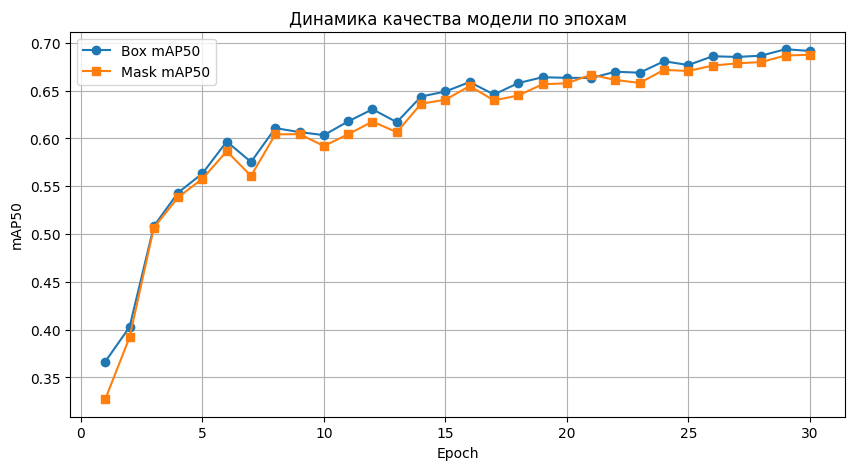

In [13]:
results = pd.read_csv('/content/runs/segment/results/yolov8n_car_damage/results.csv')
results = results.dropna(axis=1, how='all')


plt.figure(figsize=(10, 5))
plt.plot(results['epoch'], results['metrics/mAP50(B)'], label='Box mAP50', marker='o')
plt.plot(results['epoch'], results['metrics/mAP50(M)'], label='Mask mAP50', marker='s')
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.title('Динамика качества модели по эпохам')
plt.legend()
plt.grid(True)
plt.show()

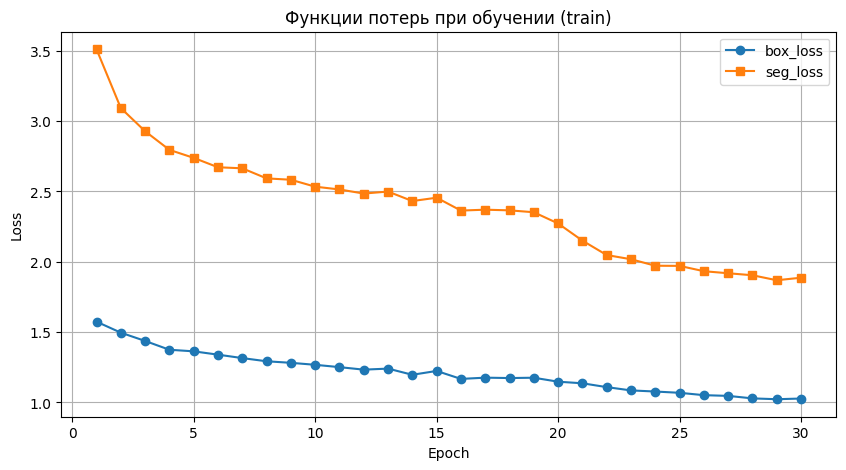

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(results['epoch'], results['train/box_loss'], label='box_loss', marker='o')
plt.plot(results['epoch'], results['train/seg_loss'], label='seg_loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Функции потерь при обучении (train)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
model = YOLO('/content/runs/segment/results/yolov8n_car_damage/weights/best.pt')


Found https://i.pinimg.com/736x/7d/ee/02/7dee02dd917598e389334c8c71c070f8.jpg locally at 7dee02dd917598e389334c8c71c070f8.jpg
image 1/1 /content/7dee02dd917598e389334c8c71c070f8.jpg: 448x640 1 scratch, 1 tire_flat, 9.1ms
Speed: 2.8ms preprocess, 9.1ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


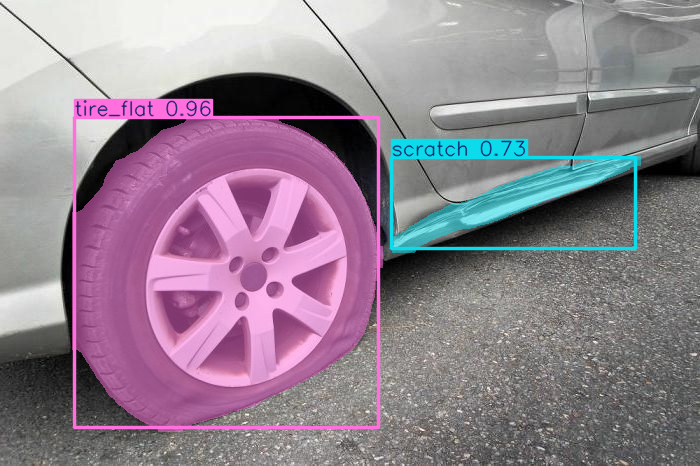

Найденные повреждения:
  - tire_flat (уверенность: 0.96)
  - scratch (уверенность: 0.73)

Found https://i.pinimg.com/736x/d4/60/8e/d4608e402d20456a2eb2a124e95dcb29.jpg locally at d4608e402d20456a2eb2a124e95dcb29.jpg
image 1/1 /content/d4608e402d20456a2eb2a124e95dcb29.jpg: 448x640 1 scratch, 10.4ms
Speed: 2.0ms preprocess, 10.4ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)


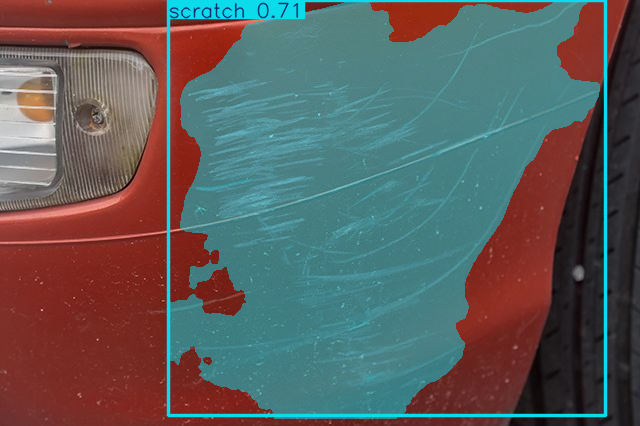

Найденные повреждения:
  - scratch (уверенность: 0.71)

Found https://a.d-cd.net/4437558s-960.jpg locally at 4437558s-960.jpg
image 1/1 /content/4437558s-960.jpg: 384x640 1 lamp_broken, 12.8ms
Speed: 3.0ms preprocess, 12.8ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)


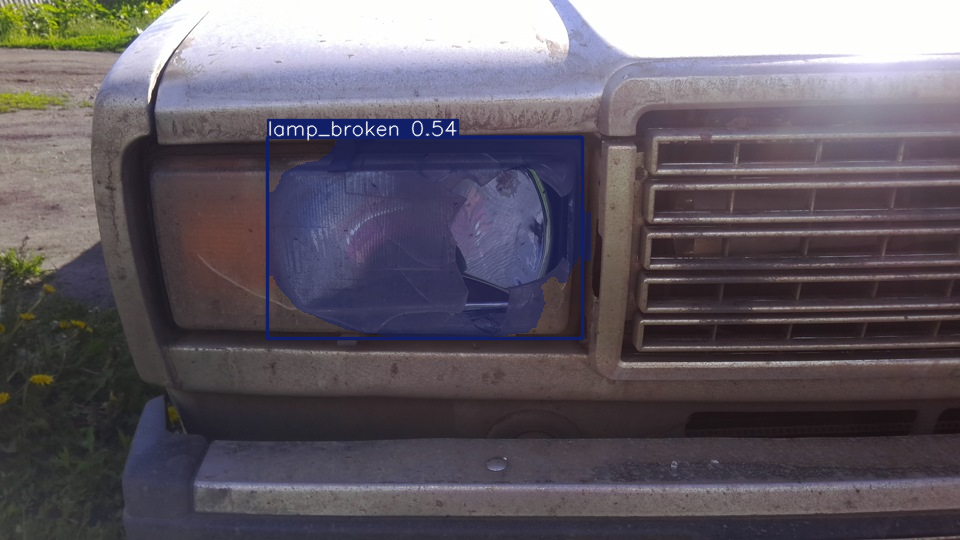

Найденные повреждения:
  - lamp_broken (уверенность: 0.54)

image 1/1 /content/maxresdefault.jpg: 384x640 (no detections), 10.5ms
Speed: 2.2ms preprocess, 10.5ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


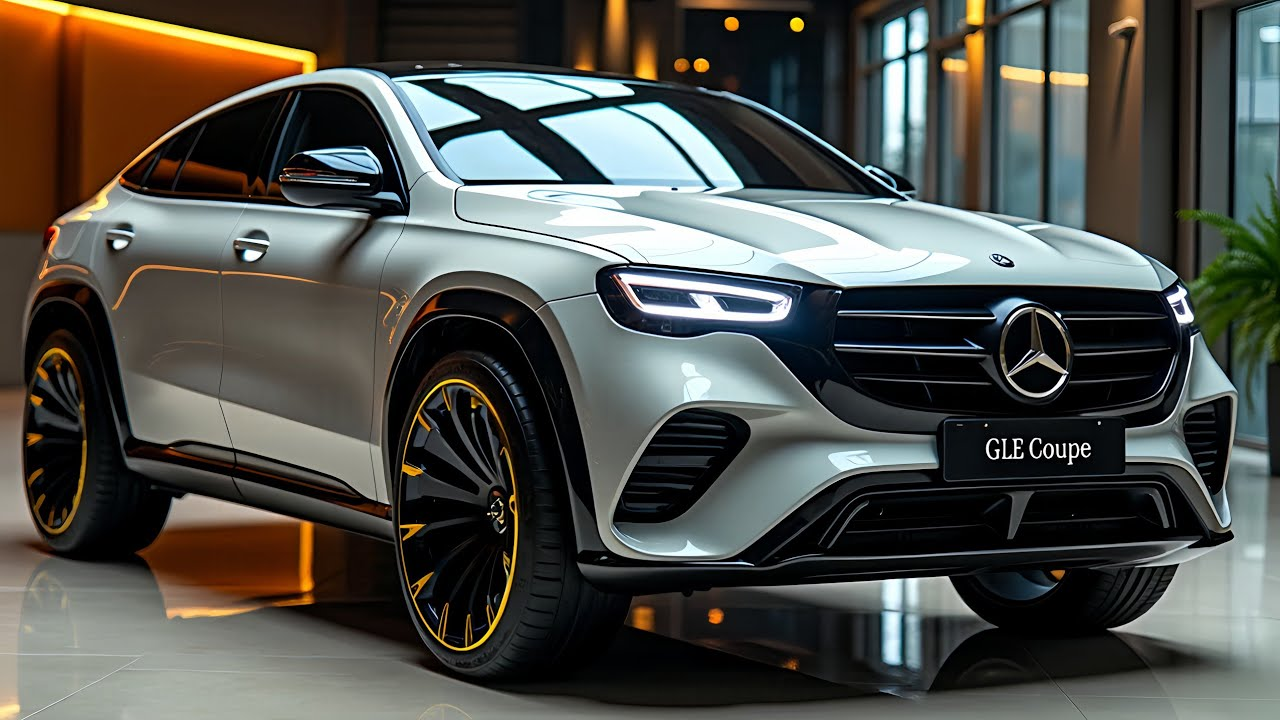

Найденные повреждения:


In [18]:
test_images = ['https://i.pinimg.com/736x/7d/ee/02/7dee02dd917598e389334c8c71c070f8.jpg',
              'https://i.pinimg.com/736x/d4/60/8e/d4608e402d20456a2eb2a124e95dcb29.jpg',
               'https://a.d-cd.net/4437558s-960.jpg',
               'https://i.ytimg.com/vi/pMZxrgfY-dE/maxresdefault.jpg']
for test_image in test_images:
  results = model(test_image)
  results[0].show()

  print("Найденные повреждения:")
  for r in results:
      if r.masks is not None:
          for i, cls in enumerate(r.boxes.cls):
              class_name = r.names[int(cls)]
              confidence = float(r.boxes.conf[i])
              print(f"  - {class_name} (уверенность: {confidence:.2f})")